In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from tqdm import tqdm

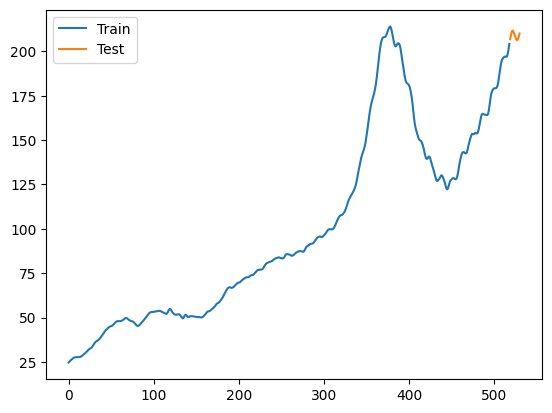

In [3]:
os.chdir("C:/Python/Datasets")
df = pd.read_csv("FMAC-HPI_24420.csv")
y = df['NSA Value']
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Test')
plt.legend()
plt.show()

#### Holt's Linear Trend

In [5]:
alphas = np.linspace(0.01, 0.9, 10)
betas = np.linspace(0.01, 0.9, 10)
scores = []

for i in tqdm(range(len(alphas))):
    for b in betas:
        hw_add = Holt(y_train)
        fit1 = hw_add.fit(smoothing_level=alphas[i],smoothing_trend=b)
        y_pred = fit1.forecast(len(y_test))
        scores.append([alphas[i], b,root_mean_squared_error(y_test, y_pred) ])


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_de

In [7]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.900000
beta     0.010000
score    3.310199
Name: 90, dtype: float64

#### Holt's Exponential Trend

In [11]:
alphas = np.linspace(0.01, 0.9, 10)
betas = np.linspace(0.01, 0.9, 10)
scores = []

for i in tqdm(range(len(alphas))):
    for b in betas:
        hw_add = Holt(y_train, exponential=True)
        fit1 = hw_add.fit(smoothing_level=alphas[i],smoothing_trend=b)
        y_pred = fit1.forecast(len(y_test))
        scores.append([alphas[i], b,root_mean_squared_error(y_test, y_pred) ])


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_de

In [13]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.108889
beta     0.702222
score    3.325729
Name: 17, dtype: float64

#### Additive Damped Trend

In [16]:
alphas = np.linspace(0.01, 0.9, 10)
betas = np.linspace(0.01, 0.9, 10)
phis = np.linspace(0.01, 0.9, 10)
scores = []

for i in tqdm(range(len(alphas))):
    for b in betas:
        for p in phis:
            hw_add = Holt(y_train, damped_trend=True)
            fit1 = hw_add.fit(smoothing_level=alphas[i],smoothing_trend=b,damping_trend=p)
            y_pred = fit1.forecast(len(y_test))
            scores.append([alphas[i], b,p,root_mean_squared_error(y_test, y_pred) ])

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_de

In [18]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','phi','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.900000
beta     0.900000
phi      0.603333
score    2.161702
Name: 996, dtype: float64

#### Multiplicative Damped Trend

In [21]:
alphas = np.linspace(0.01, 0.9, 10)
betas = np.linspace(0.01, 0.9, 10)
phis = np.linspace(0.01, 0.9, 10)
scores = []

for i in tqdm(range(len(alphas))):
    for b in betas:
        for p in phis:
            hw_add = Holt(y_train, damped_trend=True, exponential=True)
            fit1 = hw_add.fit(smoothing_level=alphas[i],smoothing_trend=b,damping_trend=p)
            y_pred = fit1.forecast(len(y_test))
            scores.append([alphas[i], b,p,root_mean_squared_error(y_test, y_pred) ])

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Python\anaconda3\Lib\site-packages\pandas\util\_de

In [22]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','phi','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.900000
beta     0.900000
phi      0.603333
score    2.141941
Name: 996, dtype: float64

#### Best Model:

In [30]:
hw_add = Holt(y_train, damped_trend=True, exponential=True)
fit1 = hw_add.fit(smoothing_level=0.9,smoothing_trend=0.9,damping_trend=0.603333, optimized=False)
y_pred = fit1.forecast(len(y_test))
root_mean_squared_error(y_test, y_pred)

2.1419413325196324

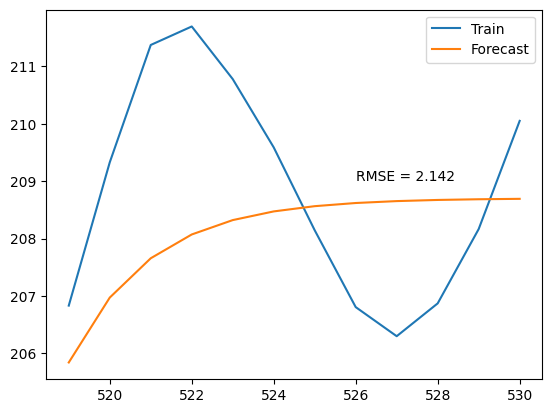

In [36]:
y_pred.index = y_test.index
plt.plot(y_test, label='Train')
plt.plot(y_pred, label='Forecast')
error = str(np.round(root_mean_squared_error(y_test, y_pred),3))
plt.text(526, 209, "RMSE = "+error) 
plt.legend()
plt.show()